In [442]:
import numpy as np
import matplotlib.pyplot as plt

In [443]:
#f = lambda x: np.exp(-np.linalg.norm(x))
f = lambda x: np.exp(-x) # 1d case

In [444]:
# - d2y/dx2 == f
# y = -e**(-x) + ax + b
u_analytic = lambda x, c1=0, c2=0: -np.exp(-x) + c1*x + c2

In [445]:
a = -1
b = 1
(a,b)

(-1, 1)

In [446]:
uD_a = u_analytic(a)
uD_b = u_analytic(b)
uD_a, uD_b

(np.float64(-2.718281828459045), np.float64(-0.36787944117144233))

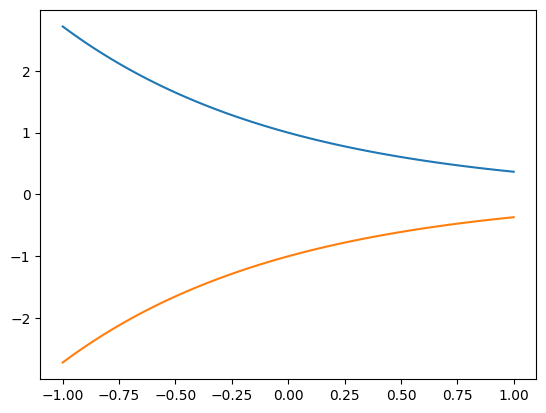

In [447]:
x = np.linspace(a, b, 100)
plt.plot(x, f(x))
#plt.plot(x, u(x, c1=-1))
plt.plot(x, u_analytic(x))
#plt.plot(x, u(x, c1=1))

# 1) finite differences + conjugate gradients

In [448]:
N = 64
dim = 1


diag_mult = 2*dim
I = np.identity(N)
U = -np.roll(I,1)
U[0,0] = 0
L = -np.roll(I,-1)
L[-1,-1] = 0
J = diag_mult*I+U+L
J

array([[ 2., -1.,  0., ...,  0.,  0.,  0.],
       [-1.,  2., -1., ...,  0.,  0.,  0.],
       [ 0., -1.,  2., ...,  0.,  0.,  0.],
       ...,
       [ 0.,  0.,  0., ...,  2., -1.,  0.],
       [ 0.,  0.,  0., ..., -1.,  2., -1.],
       [ 0.,  0.,  0., ...,  0., -1.,  2.]], shape=(64, 64))

In [449]:
from scipy.sparse.linalg import cg

In [450]:
x = np.linspace(a, b, N+2)
h = x[1]-x[0]
x_inner = x[1:-1]
uD = np.zeros_like(x_inner)
uD[0] = uD_a
uD[-1] = uD_b
rhs = h**2 * f(x_inner) + uD

u_cg_inner, info = cg(J, rhs)
u_cg = np.zeros(N+2)
u_cg[1:-1] = u_cg_inner
u_cg[0] = uD_a
u_cg[-1] = uD_b

print("Solution:", u_cg_inner)
print("Convergence info:", info)


Solution: [-2.6359197  -2.55605311 -2.47860644 -2.40350638 -2.33068181 -2.26006379
 -2.19158545 -2.12518197 -2.06079048 -1.99835    -1.93780142 -1.87908743
 -1.82215241 -1.76694249 -1.71340537 -1.66149038 -1.61114836 -1.56233165
 -1.51499403 -1.46909069 -1.42457817 -1.38141432 -1.33955827 -1.29897041
 -1.2596123  -1.22144668 -1.18443742 -1.14854947 -1.11374887 -1.08000267
 -1.04727891 -1.01554662 -0.98477575 -0.95493717 -0.92600263 -0.89794475
 -0.87073695 -0.84435348 -0.81876936 -0.79396036 -0.76990302 -0.74657454
 -0.72395284 -0.70201651 -0.68074477 -0.6601175  -0.64011516 -0.62071882
 -0.60191012 -0.58367125 -0.56598494 -0.54883445 -0.53220354 -0.51607648
 -0.50043799 -0.48527327 -0.47056797 -0.45630816 -0.44248035 -0.42907144
 -0.41606874 -0.40345995 -0.39123313 -0.3793767 ]
Convergence info: 0


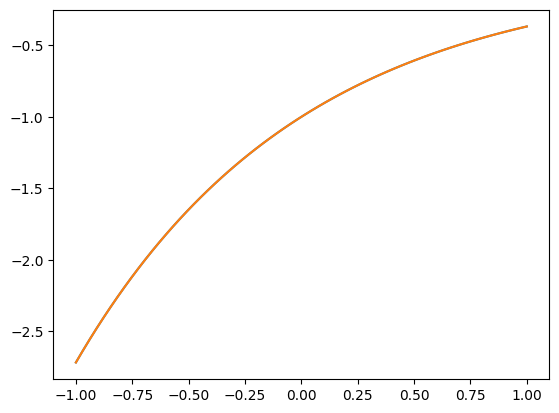

In [451]:
plt.plot(x, u_cg)
plt.plot(x, u_analytic(x, c1=0))

# 2) just Fourier transf. & Inverse Fourier transf.

In [452]:
x = np.linspace(a, b, N)
F = np.array([ f(xi) for xi in x])
F.shape

(64,)

In [453]:
F_ft = np.fft.fft(F)
F_ft.shape

(64,)

In [454]:
u_ft = np.zeros_like(F_ft)
for i in range(F_ft.shape[0]):
    if i == 0:
        u_ft[0] = 0
    else:
        #u_ft[i] = F_ft[i] / (2*np.pi/N*i)**2
        u_ft[i] = F_ft[i] / i**2
u_ft.shape

(64,)

In [455]:
u_f = np.fft.ifft(u_ft)

In [456]:
#plt.plot(u(np.linspace(-10,10,100)))

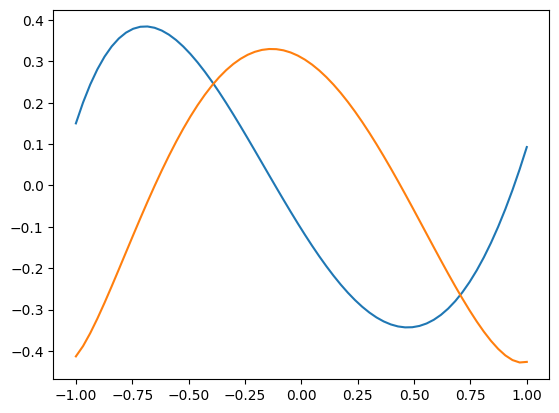

In [457]:
plt.plot(x, u_f.real)
plt.plot(x, u_f.imag)

## using sine transform

In [472]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fftpack import dst, idst

# Define the grid
N = 256  # Number of grid points
L = 2    # Domain length (from -1 to 1)
dx = L / (N + 1)  # Grid spacing
x = np.linspace(-1, 1, N, endpoint=False)  # Discretized x

# Define the source term f(x) = e^(-x)
f = np.exp(-x)

# Apply the DST (Discrete Sine Transform)
f_tilde = dst(f, type=1)

# Define sine wave numbers for DST
k = np.pi * np.arange(1, N + 1) / L  # Sine wave numbers

# Solve for u_tilde in Fourier space
u_tilde = -f_tilde / (k**2)  # Solving Poisson in transformed space

# Compute inverse DST to get u(x)
u = idst(u_tilde, type=1) / (2 * (N + 1))

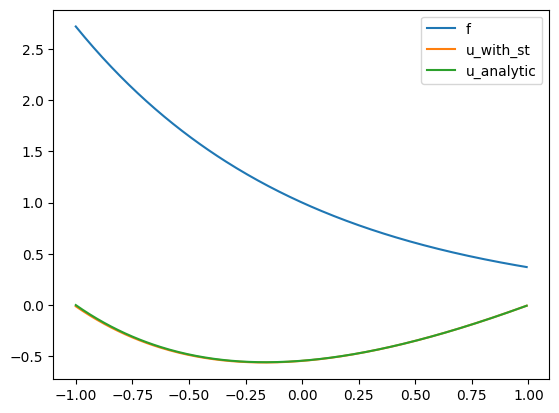

In [471]:
u_analytic_no_minus = lambda x, c1=0, c2=0: np.exp(-x) + c1*x + c2
# Plot the results
plt.plot(x, f, label="f")
plt.plot(x, u, label="u_with_st")
plt.plot(x, u_analytic_no_minus(x, -(1/np.e-np.e)/2, -(1/np.e+np.e)/2), label="u_analytic")
plt.legend()
plt.show()